# Setup and Dowload Datasets

In [4]:
# base URL for the raw files from github
BASE_URL = "https://raw.githubusercontent.com/ck-cap/xai-series/refs/heads/master/"

# Download the utils script
!curl -sSO {BASE_URL}utils.py

# Download the Task 1 script (EDA)
!curl -sSO {BASE_URL}05_lrp.py

# Download dataset and put under /data folder
!mkdir -p data
!curl -sSL -o data/brain_mri.zip https://github.com/SartajBhuvaji/Brain-Tumor-Classification-DataSet/archive/refs/heads/master.zip

# Unzip the datasets 
!unzip -q -o data/brain_mri.zip -d data/

# Create target directories
!mkdir -p data/brain_mri/training
!mkdir -p data/brain_mri/testing

# Move the class folders (not the Training/Testing folders themselves)
!mv data/Brain-Tumor-Classification-DataSet-master/Training/* data/brain_mri/training/
!mv data/Brain-Tumor-Classification-DataSet-master/Testing/* data/brain_mri/testing/

# Clean up temporary files
!rm -rf data/Brain-Tumor-Classification-DataSet-master
!rm data/brain_mri.zip

# list the files to check is everything is downloaded
!ls -la data/brain_mri


total 16
drwxr-xr-x 4 root root 4096 Dec 19 17:23 .
drwxr-xr-x 3 root root 4096 Dec 19 17:23 ..
drwxr-xr-x 6 root root 4096 Dec 19 17:23 testing
drwxr-xr-x 6 root root 4096 Dec 19 17:23 training


# Execute 05_lrp.py

## Import required libraries and check GPU availability

In [5]:
# Enable inline plotting
%matplotlib inline

# Import required libraries
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import copy
import pandas as pd

# Check if GPU is available
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")

CUDA available: True
GPU device: Tesla T4


## Run LRP

True


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


tensor(1.3934, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.4237, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2894, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2505, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.3802, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2929, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2268, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2690, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2715, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2488, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.0311, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2101, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.1100, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.1033, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2727, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.2611, device='cuda:0', grad_fn=<NllLossBackward0>)
tensor(1.1327, device='cuda:0', grad_fn=

/content/05_lrp.py:176: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  activations[-1] = torch.FloatTensor([one_hot_output]).to(device)
/content/05_lrp.py:176: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  activations[-1] = torch.FloatTensor([one_hot_output]).to(device)


Groundtruth for this image:  no_tumor


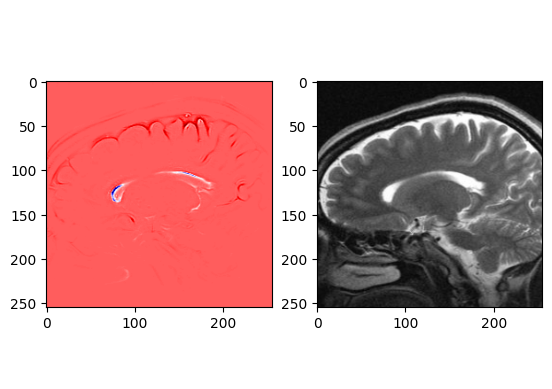

<Figure size 640x480 with 0 Axes>

In [6]:
%run 05_lrp.py

## Run LRP on multiple images

Image 0: no_tumor - Correctly classified


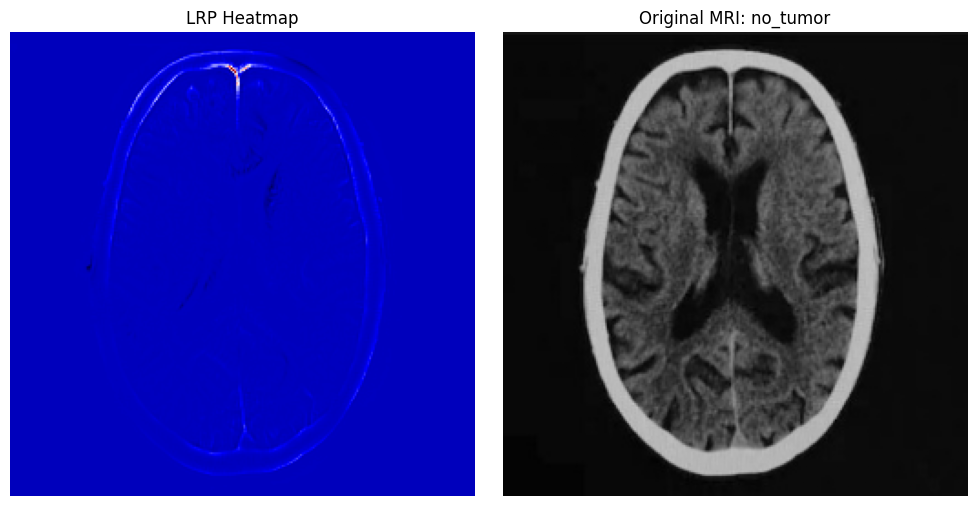

Image 1: Incorrectly classified - Skipping
Image 2: Incorrectly classified - Skipping
Error processing image 3: not a sequence
Image 4: Incorrectly classified - Skipping
Image 5: pituitary_tumor - Correctly classified


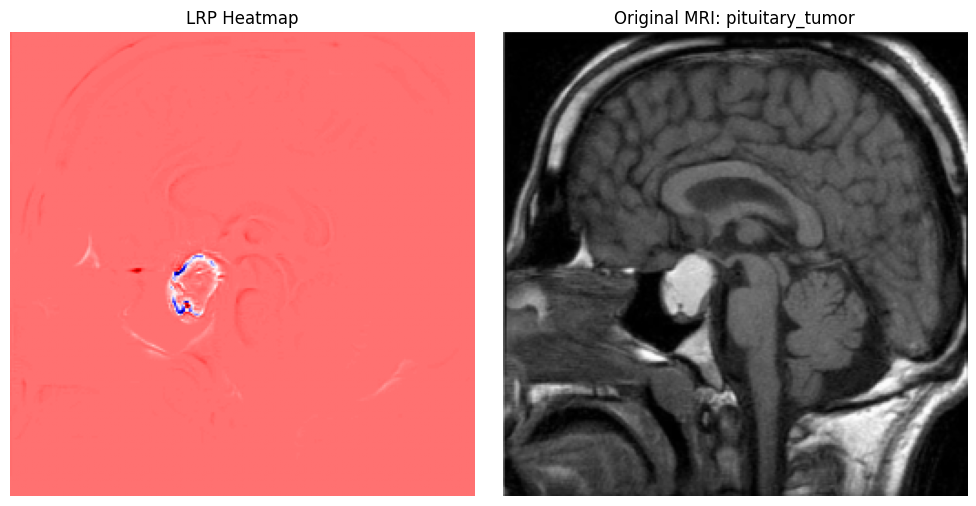

Image 6: meningioma_tumor - Correctly classified


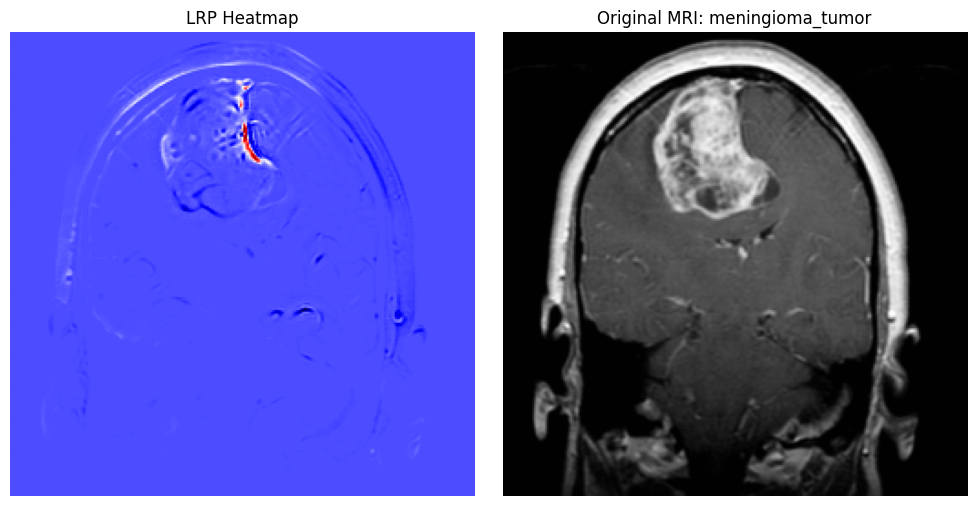

Image 7: no_tumor - Correctly classified


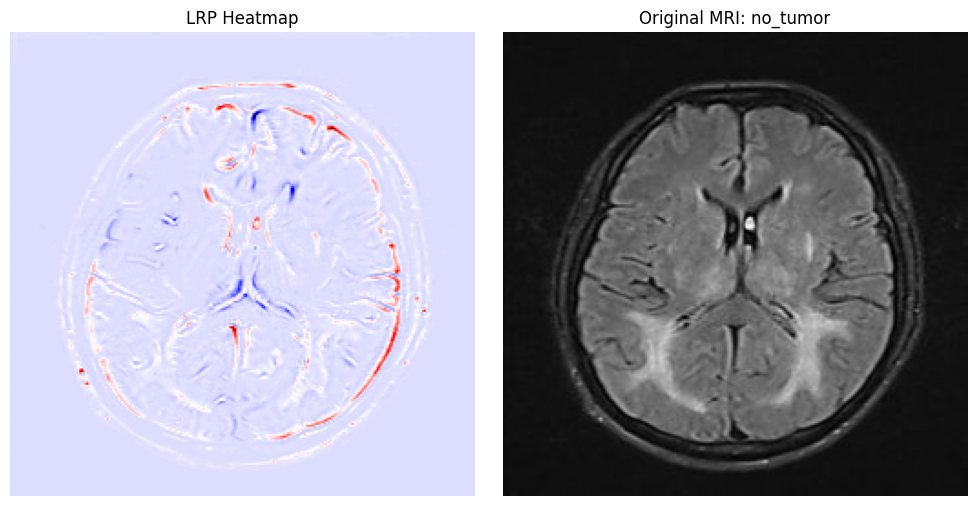

Image 8: Incorrectly classified - Skipping
Image 9: no_tumor - Correctly classified


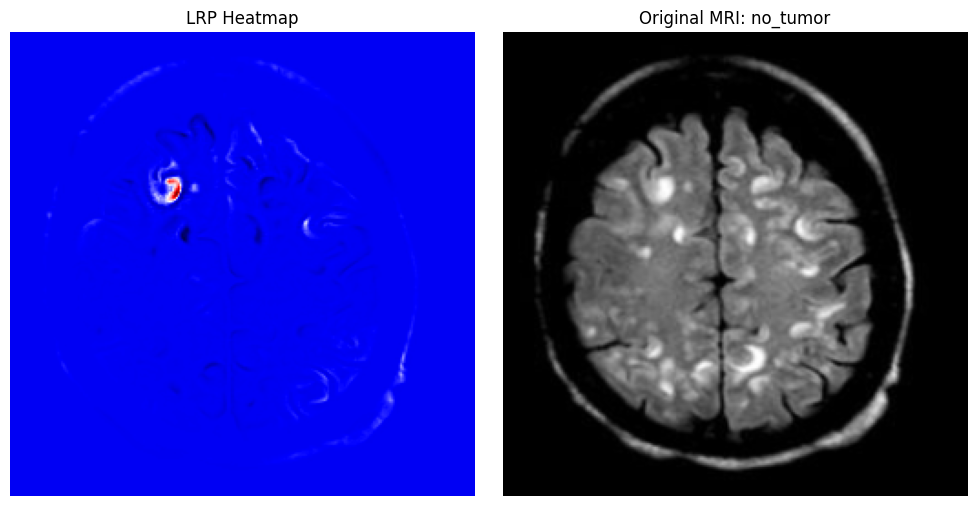

In [7]:
# Run LRP on multiple images and display
for image_id in range(10):  # Process 10 images in the batch
    try:
        image_relevances = apply_lrp_on_vgg16(model, inputs[image_id])
        image_relevances = image_relevances.permute(0,2,3,1).detach().cpu().numpy()[0]
        image_relevances = np.interp(image_relevances, 
                                     (image_relevances.min(), image_relevances.max()), 
                                     (0, 1))
        
        # Get the label name
        pred_label = list(test_dataset.class_to_idx.keys())[
                     list(test_dataset.class_to_idx.values()).index(labels[image_id])]
        
        # Only show correctly classified images
        if outputs[image_id] == labels[image_id]:
            print(f"Image {image_id}: {pred_label} - Correctly classified")
            
            # Display side by side
            fig, axes = plt.subplots(1, 2, figsize=(10, 5))
            axes[0].imshow(image_relevances[:,:,0], cmap="seismic")
            axes[0].set_title(f"LRP Heatmap")
            axes[0].axis('off')
            
            axes[1].imshow(inputs[image_id].permute(1,2,0).detach().cpu().numpy())
            axes[1].set_title(f"Original MRI: {pred_label}")
            axes[1].axis('off')
            
            plt.tight_layout()
            plt.show()
        else:
            print(f"Image {image_id}: Incorrectly classified - Skipping")
            
    except Exception as e:
        print(f"Error processing image {image_id}: {e}")

# Implementing Grad-CAM

In [8]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks to capture gradients and activations
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_image, target_class=None):
        # Forward pass
        model_output = self.model(input_image)
        
        if target_class is None:
            target_class = model_output.argmax(dim=1).item()
        
        # Zero gradients
        self.model.zero_grad()
        
        # Backward pass for the target class
        class_loss = model_output[0, target_class]
        class_loss.backward()
        
        # Get the gradients and activations
        gradients = self.gradients[0]  # (C, H, W)
        activations = self.activations[0]  # (C, H, W)
        
        # Global average pooling on gradients
        weights = gradients.mean(dim=(1, 2))  # (C,)
        
        # Weighted combination of activation maps
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(input_image.device)
        for i, w in enumerate(weights):
            cam += w * activations[i]
        
        # Apply ReLU to keep only positive influences
        cam = F.relu(cam)
        
        # Normalize to [0, 1]
        cam = cam - cam.min()
        cam = cam / cam.max()
        
        return cam.cpu().numpy(), target_class

def apply_gradcam_on_vgg16(model, image, target_class=None):
    # Get the last convolutional layer in VGG16
    target_layer = model.vgg16.features[30]  # Last conv layer before pooling
    
    # Initialize Grad-CAM
    gradcam = GradCAM(model, target_layer)
    
    # Add batch dimension
    image_batch = image.unsqueeze(0).to(device)
    
    # Generate CAM
    cam, pred_class = gradcam.generate_cam(image_batch, target_class)
    
    # Resize CAM to match input image size
    cam_resized = cv2.resize(cam, (image.shape[2], image.shape[1]))
    
    return cam_resized, pred_class

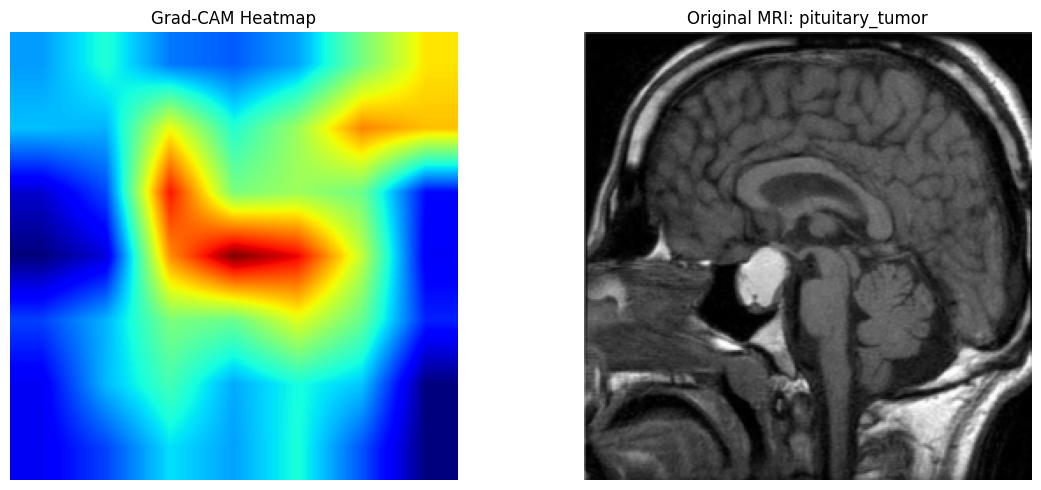

Ground truth: pituitary_tumor
Predicted class: 2


In [30]:
# Test Grad-CAM
image_id = 5 

# Apply Grad-CAM
gradcam_heatmap, predicted_class = apply_gradcam_on_vgg16(model, inputs[image_id])

# Get label name
pred_label = list(test_dataset.class_to_idx.keys())[
             list(test_dataset.class_to_idx.values()).index(labels[image_id])]

# Display results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Grad-CAM heatmap
axes[0].imshow(gradcam_heatmap, cmap='jet')
axes[0].set_title('Grad-CAM Heatmap')
axes[0].axis('off')

# Original image
axes[1].imshow(inputs[image_id].permute(1,2,0).detach().cpu().numpy())
axes[1].set_title(f'Original MRI: {pred_label}')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Ground truth: {pred_label}")
print(f"Predicted class: {predicted_class}")

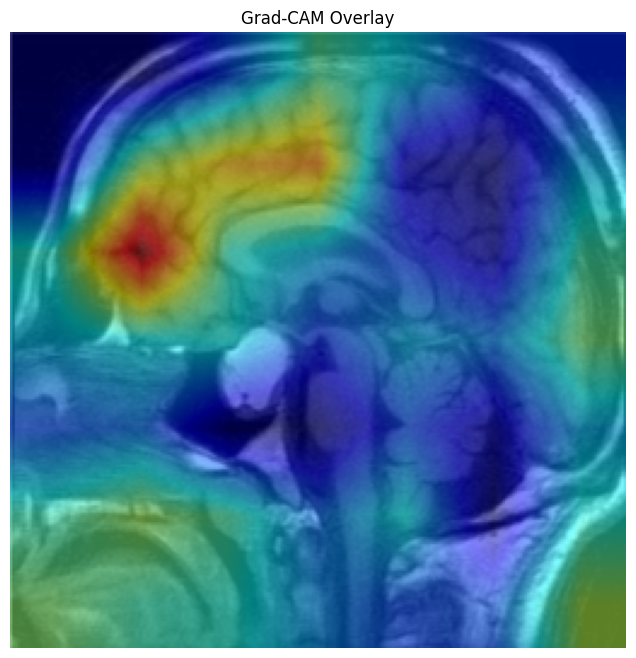

In [15]:
def create_gradcam_overlay(image, heatmap, alpha=0.4):
    # Convert heatmap to RGB
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Convert image to proper format
    image_np = (image * 255).astype(np.uint8)
    
    # Overlay
    overlay = cv2.addWeighted(image_np, 1-alpha, heatmap_colored, alpha, 0)
    
    return overlay

# Example usage:
image_np = inputs[image_id].permute(1,2,0).detach().cpu().numpy()
overlay = create_gradcam_overlay(image_np, gradcam_heatmap, alpha=0.5)

plt.figure(figsize=(8, 8))
plt.imshow(overlay)
plt.title('Grad-CAM Overlay')
plt.axis('off')
plt.show()

Image 0: no_tumor - Correctly classified


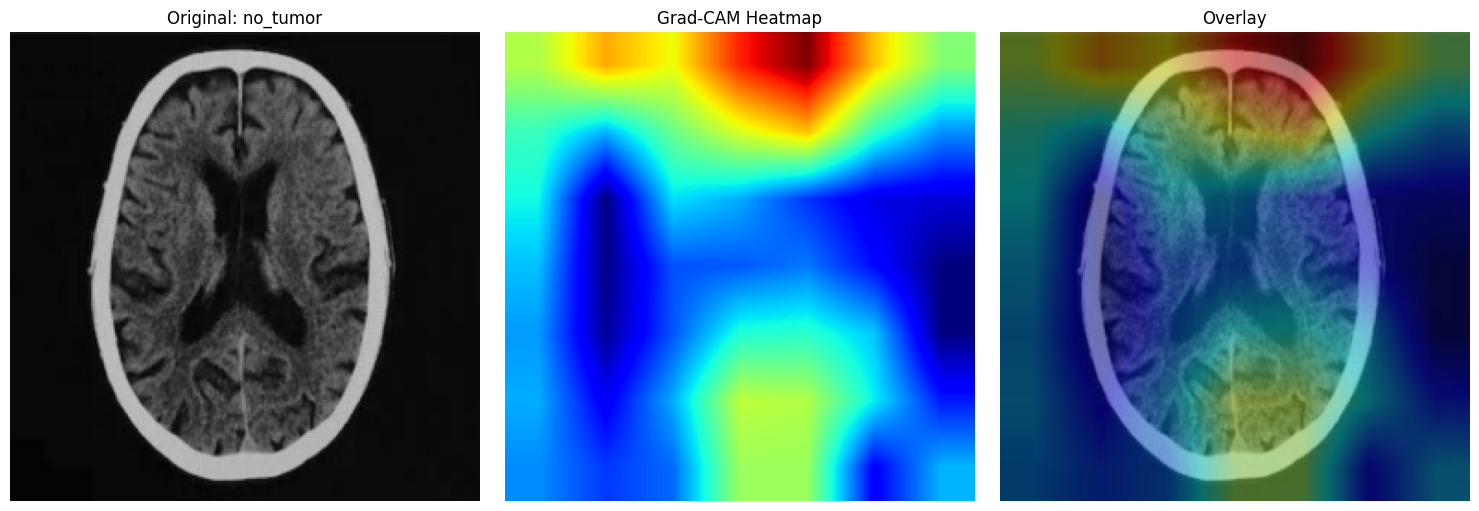

Image 1: Misclassified - Skipping
Image 2: Misclassified - Skipping
Image 3: glioma_tumor - Correctly classified


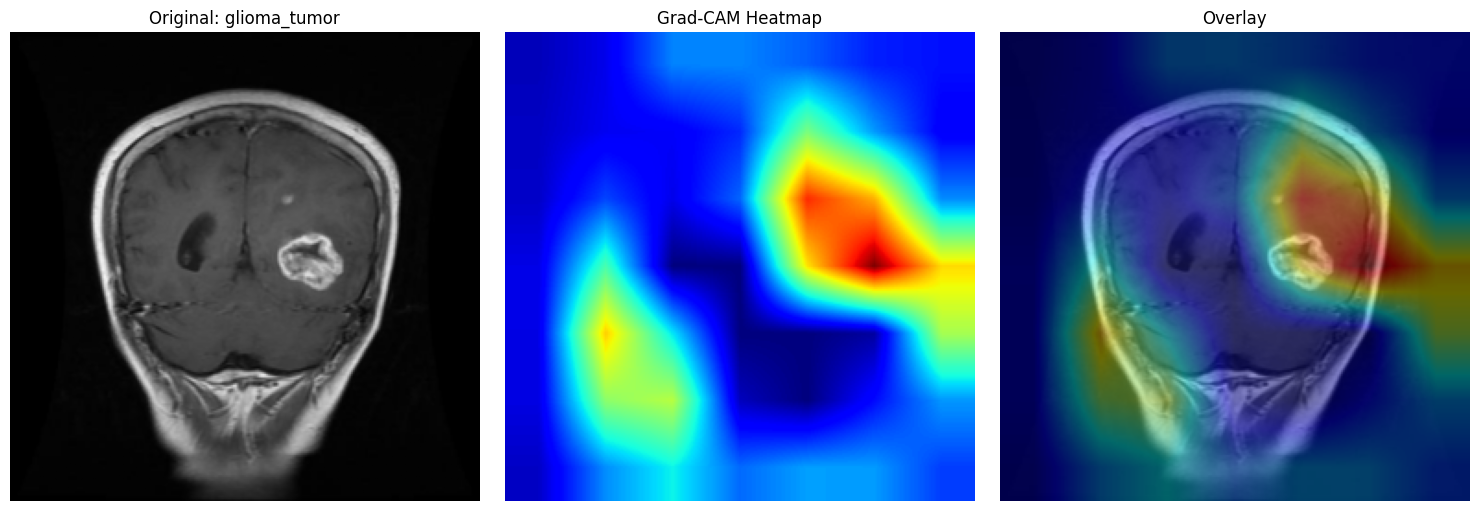

Image 4: Misclassified - Skipping
Image 5: pituitary_tumor - Correctly classified


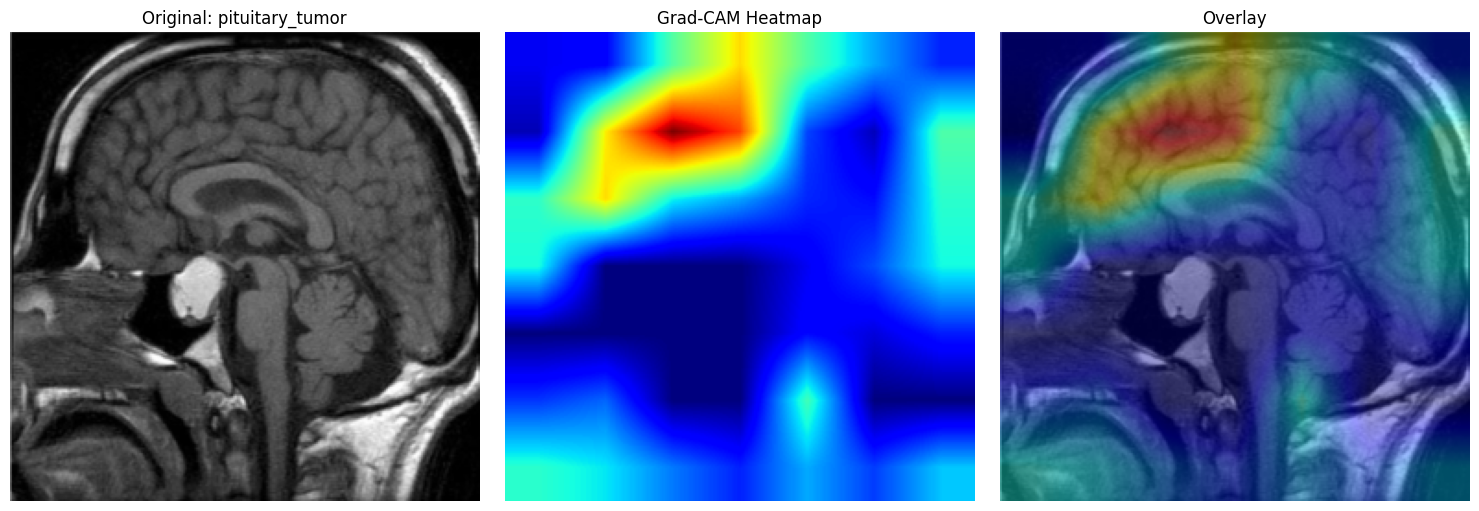

Image 6: meningioma_tumor - Correctly classified


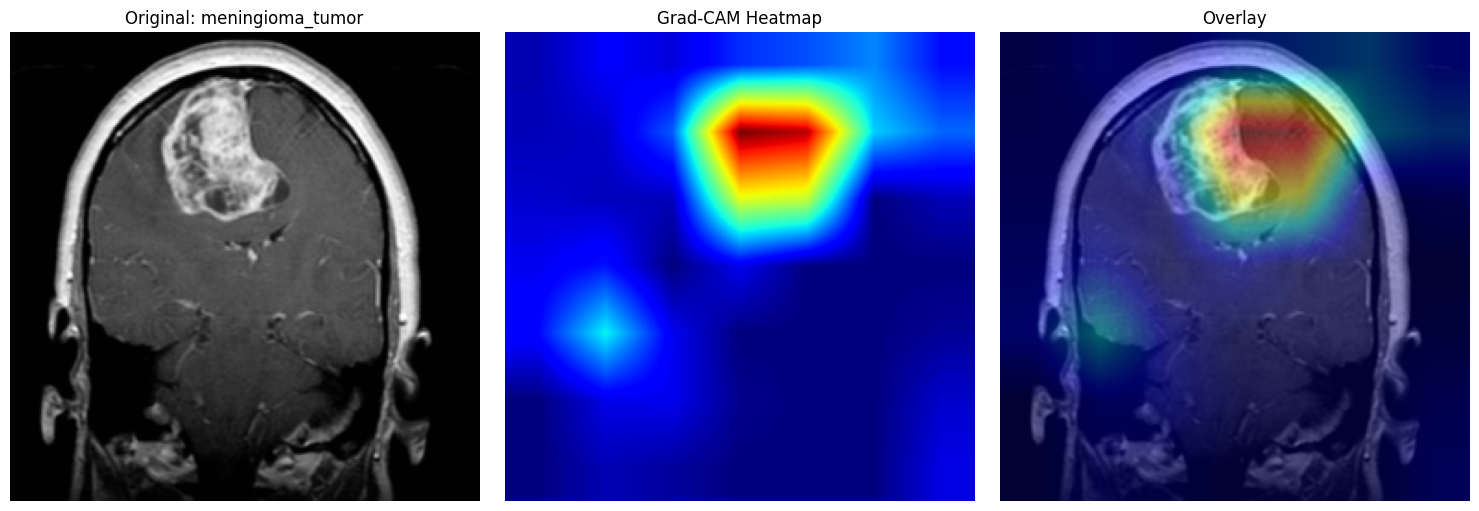

Image 7: no_tumor - Correctly classified


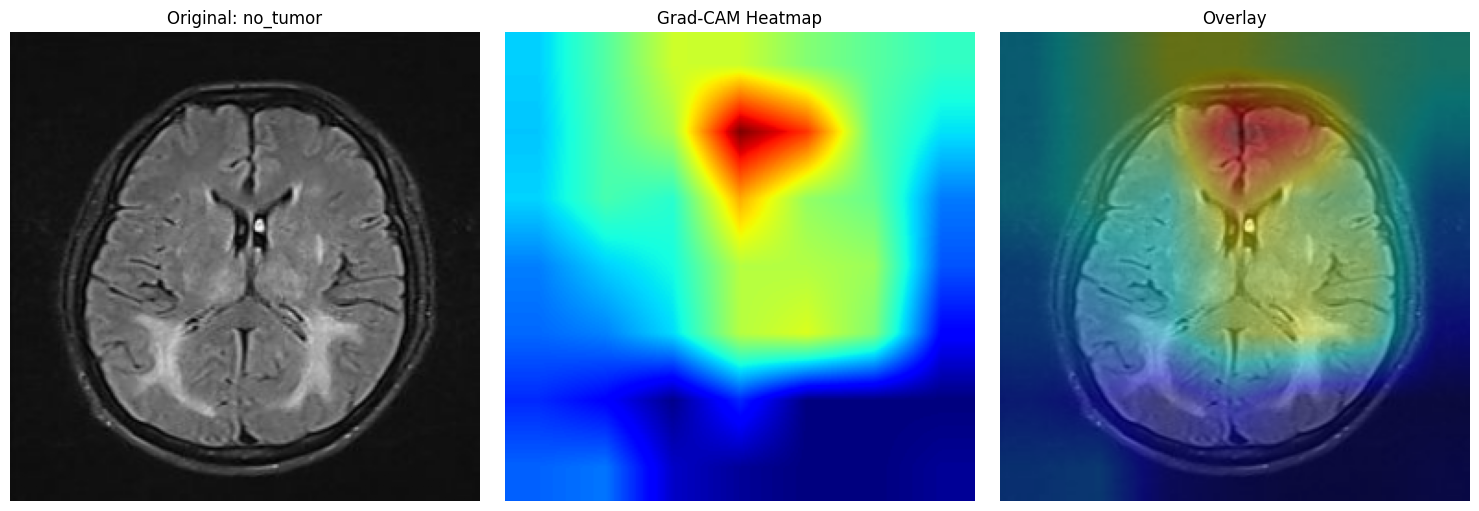

Image 8: Misclassified - Skipping
Image 9: no_tumor - Correctly classified


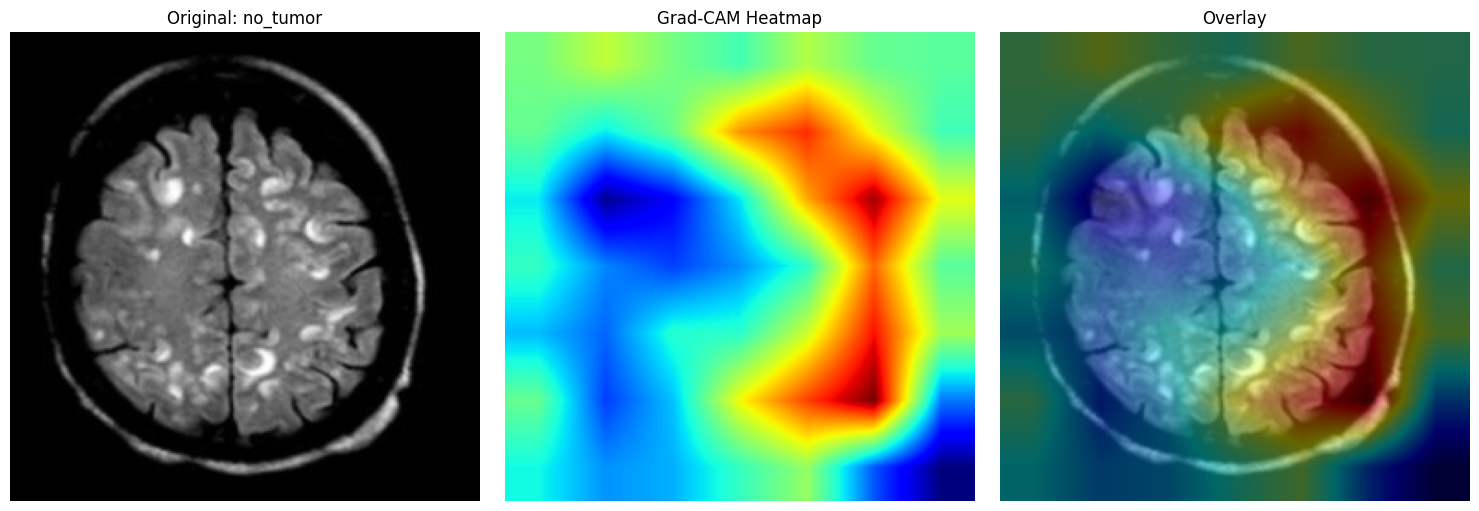

In [33]:
# Run Grad-CAM on multiple images
for image_id in range(10):
    try:
        # Apply Grad-CAM
        gradcam_heatmap, predicted_class = apply_gradcam_on_vgg16(model, inputs[image_id])
        
        # Get label
        pred_label = list(test_dataset.class_to_idx.keys())[
                     list(test_dataset.class_to_idx.values()).index(labels[image_id])]
        
        # Only show correctly classified images
        if outputs[image_id] == labels[image_id]:
            print(f"Image {image_id}: {pred_label} - Correctly classified")
            
            # Create three-panel visualization
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # Original image
            axes[0].imshow(inputs[image_id].permute(1,2,0).detach().cpu().numpy())
            axes[0].set_title(f'Original: {pred_label}')
            axes[0].axis('off')
            
            # Grad-CAM heatmap
            axes[1].imshow(gradcam_heatmap, cmap='jet')
            axes[1].set_title('Grad-CAM Heatmap')
            axes[1].axis('off')
            
            # Overlay
            image_np = inputs[image_id].permute(1,2,0).detach().cpu().numpy()
            overlay = create_gradcam_overlay(image_np, gradcam_heatmap)
            axes[2].imshow(overlay)
            axes[2].set_title('Overlay')
            axes[2].axis('off')
            
            plt.tight_layout()
            plt.show()
        else:
            print(f"Image {image_id}: Misclassified - Skipping")
            
    except Exception as e:
        print(f"Error processing image {image_id}: {e}")

## Compare LRP with Grad-CAM

Successfully processed image 5: pituitary_tumor
Successfully processed image 6: meningioma_tumor
Successfully processed image 7: no_tumor


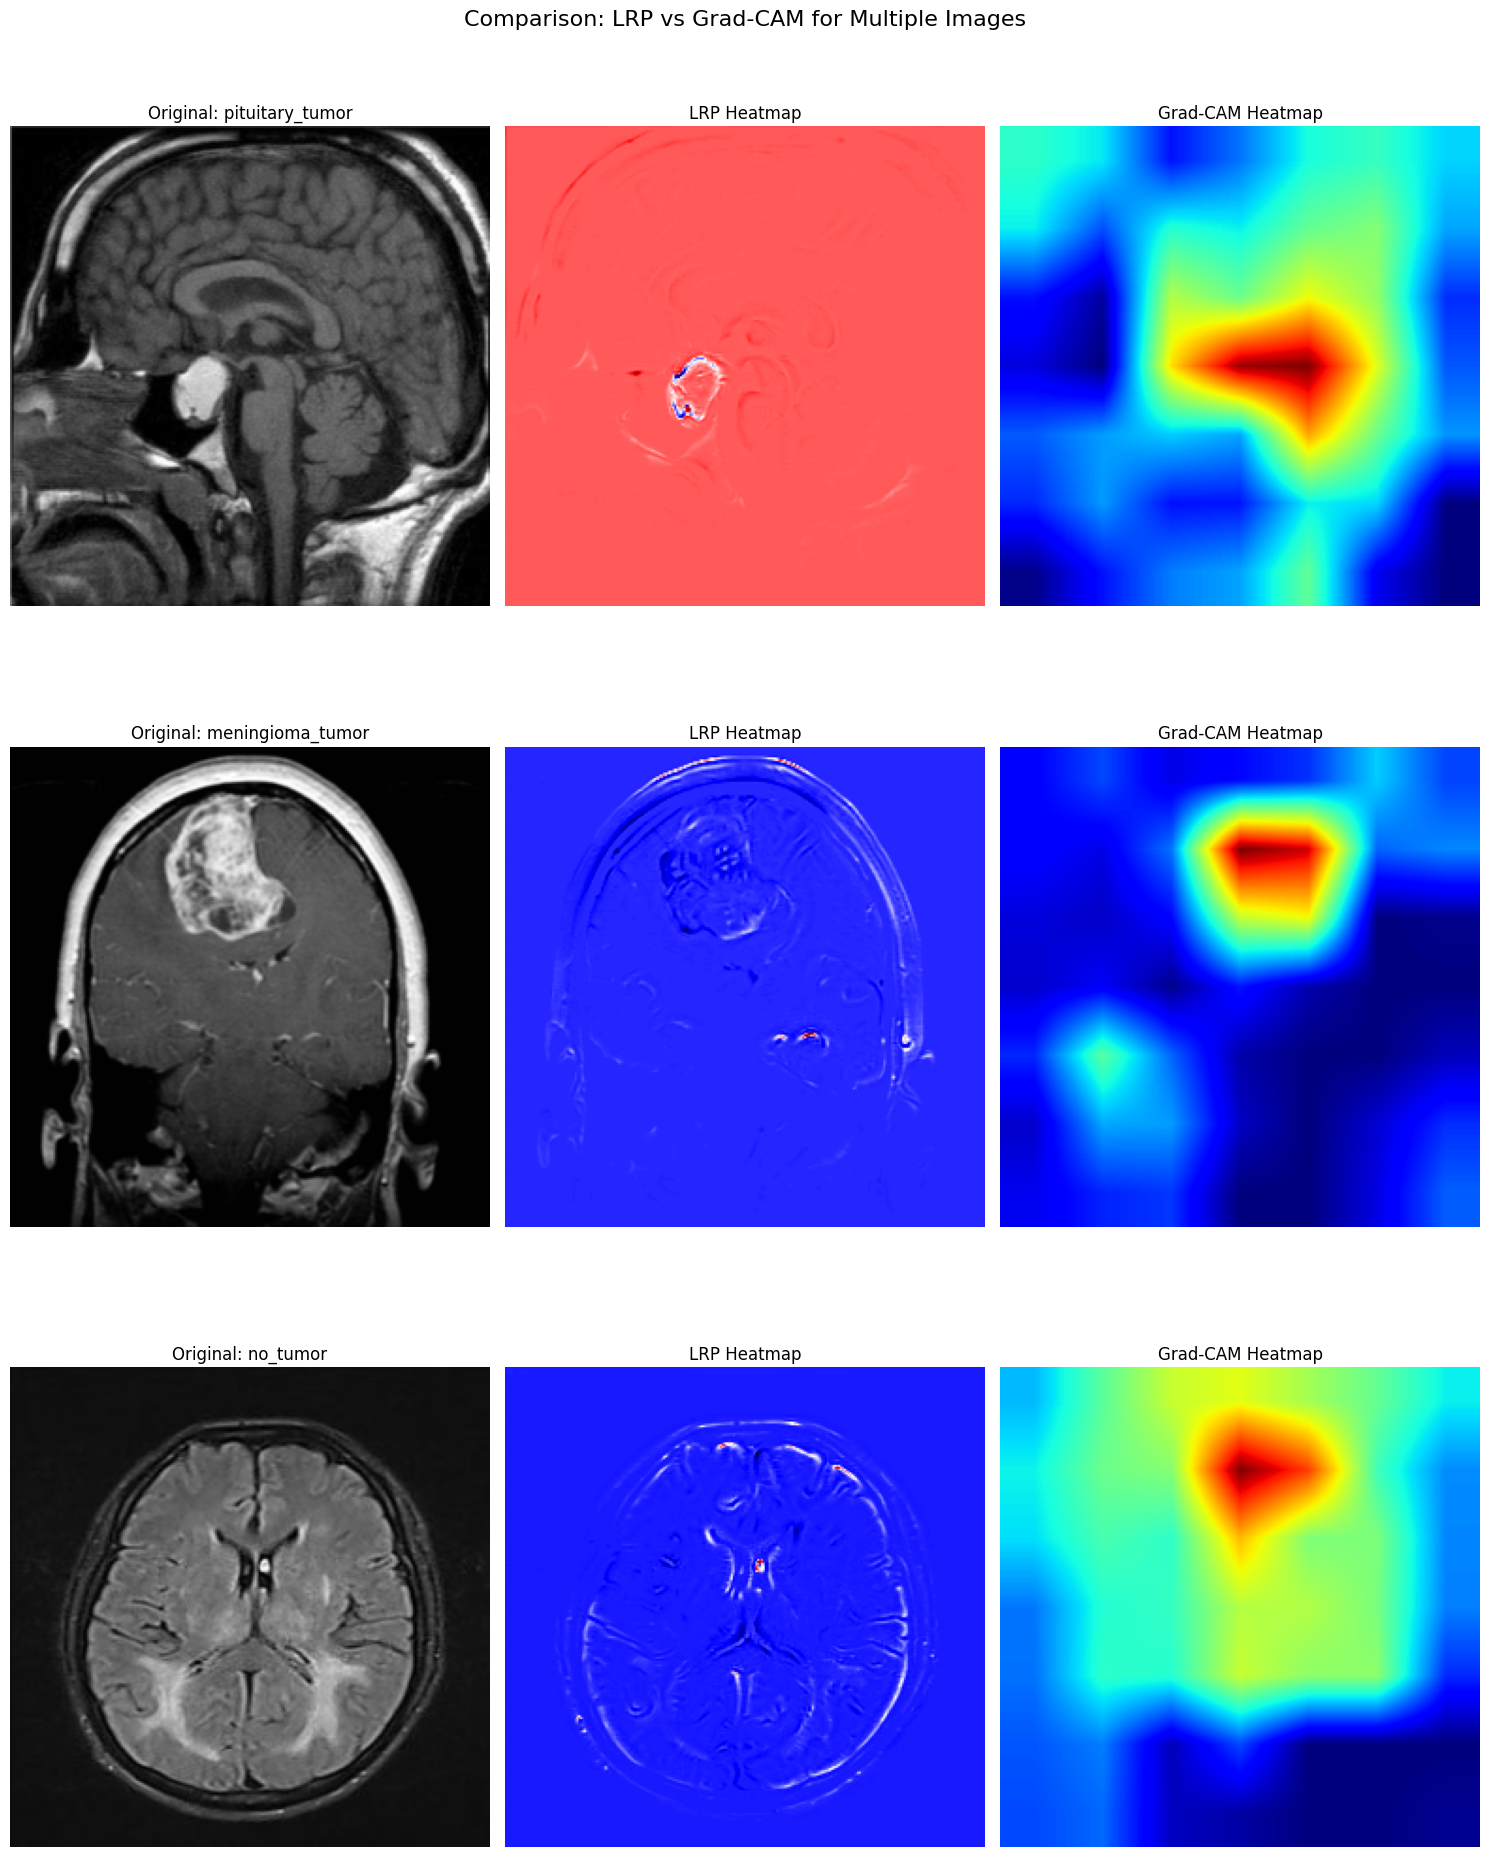

In [40]:
# Compare both methods on multiple images
image_ids = [5, 6, 7]  # Pick multiple images

# Create subplot grid for 4 images
fig, axes = plt.subplots(3, 3, figsize=(15, 20))

for row_idx, image_id in enumerate(image_ids):
    try:
        # Get LRP
        image_relevances = apply_lrp_on_vgg16(model, inputs[image_id])
        image_relevances = image_relevances.permute(0,2,3,1).detach().cpu().numpy()[0]
        lrp_heatmap = np.interp(image_relevances[:,:,0], 
                                (image_relevances[:,:,0].min(), image_relevances[:,:,0].max()), 
                                (0, 1))
        
        # Get Grad-CAM
        gradcam_heatmap, _ = apply_gradcam_on_vgg16(model, inputs[image_id])
        
        # Get label
        pred_label = list(test_dataset.class_to_idx.keys())[
                     list(test_dataset.class_to_idx.values()).index(labels[image_id])]
        
        # Original
        axes[row_idx, 0].imshow(inputs[image_id].permute(1,2,0).detach().cpu().numpy())
        axes[row_idx, 0].set_title(f'Original: {pred_label}')
        axes[row_idx, 0].axis('off')
        
        # LRP
        axes[row_idx, 1].imshow(lrp_heatmap, cmap='seismic')
        axes[row_idx, 1].set_title('LRP Heatmap')
        axes[row_idx, 1].axis('off')
        
        # Grad-CAM
        axes[row_idx, 2].imshow(gradcam_heatmap, cmap='jet')
        axes[row_idx, 2].set_title('Grad-CAM Heatmap')
        axes[row_idx, 2].axis('off')
        
        print(f"Successfully processed image {image_id}: {pred_label}")
        
    except Exception as e:
        print(f"Error processing image {image_id}: {e}")
        # Show blank axes for failed images
        axes[row_idx, 0].text(0.5, 0.5, f'Error on image {image_id}', 
                              ha='center', va='center', transform=axes[row_idx, 0].transAxes)
        axes[row_idx, 0].axis('off')
        axes[row_idx, 1].axis('off')
        axes[row_idx, 2].axis('off')

plt.suptitle('Comparison: LRP vs Grad-CAM for Multiple Images', fontsize=16)
plt.tight_layout()
plt.show()

## Quantitative Comparison

In [21]:
# METRIC DEFINITIONS

def compute_peak_ratio(heatmap):
    return heatmap.max() / heatmap.mean() if heatmap.mean() > 0 else 0

def compute_sparsity(heatmap, threshold=0.5):
    important_pixels = (heatmap > threshold * heatmap.max()).sum()
    total_pixels = heatmap.size
    return (important_pixels / total_pixels) * 100

# COMPUTE METRICS ACROSS MULTIPLE IMAGES

num_images_to_analyze = 10
results = {
    'lrp_peak': [],
    'gradcam_peak': [],
    'lrp_sparse': [],
    'gradcam_sparse': []
}

print("Analyzing images...")
for image_id in range(10):
    # Skip incorrectly classified images
    if outputs[image_id] != labels[image_id]:
        continue
    
    try:
        # Generate LRP heatmap
        image_relevances = apply_lrp_on_vgg16(model, inputs[image_id])
        image_relevances = image_relevances.permute(0,2,3,1).detach().cpu().numpy()[0]
        lrp_map = np.interp(image_relevances[:,:,0], 
                            (image_relevances[:,:,0].min(), image_relevances[:,:,0].max()), 
                            (0, 1))
        # Process LRP: convert to absolute deviation from neutral
        lrp_processed = np.abs(lrp_map - 0.5) * 2
        
        # Generate Grad-CAM heatmap
        gradcam_map, _ = apply_gradcam_on_vgg16(model, inputs[image_id])
        
        # Compute metrics
        results['lrp_peak'].append(compute_peak_ratio(lrp_processed))
        results['gradcam_peak'].append(compute_peak_ratio(gradcam_map))
        results['lrp_sparse'].append(compute_sparsity(lrp_processed, threshold=0.5))
        results['gradcam_sparse'].append(compute_sparsity(gradcam_map, threshold=0.5))
        
        print(f"Image {image_id} processed")
        
    except Exception as e:
        print(f"Error on image {image_id}: {e}")
        continue

print(f"\nSuccessfully analyzed {len(results['lrp_peak'])} images")

# DISPLAY SUMMARY STATISTICS

print(f"QUANTITATIVE COMPARISON: LRP vs Grad-CAM")
print(f"(Mean ± Std across {len(results['lrp_peak'])} images)")

# Metric 1: Peak Intensity Ratio
lrp_peak_mean = np.mean(results['lrp_peak'])
lrp_peak_std = np.std(results['lrp_peak'])
gradcam_peak_mean = np.mean(results['gradcam_peak'])
gradcam_peak_std = np.std(results['gradcam_peak'])

print(f"\n1. Peak Intensity Ratio (higher = more concentrated)")
print(f"   LRP:      {lrp_peak_mean:.2f} ± {lrp_peak_std:.2f}")
print(f"   Grad-CAM: {gradcam_peak_mean:.2f} ± {gradcam_peak_std:.2f}")
print(f"   → LRP is {lrp_peak_mean/gradcam_peak_mean:.2f}x more concentrated")

# Metric 2: Sparsity
lrp_sparse_mean = np.mean(results['lrp_sparse'])
lrp_sparse_std = np.std(results['lrp_sparse'])
gradcam_sparse_mean = np.mean(results['gradcam_sparse'])
gradcam_sparse_std = np.std(results['gradcam_sparse'])

print(f"\n2. Sparsity - % of Important Pixels (lower = more focused)")
print(f"   LRP:      {lrp_sparse_mean:.2f}% ± {lrp_sparse_std:.2f}%")
print(f"   Grad-CAM: {gradcam_sparse_mean:.2f}% ± {gradcam_sparse_std:.2f}%")
print(f"   → LRP focuses on {gradcam_sparse_mean/lrp_sparse_mean:.2f}x fewer pixels")

Analyzing images...
Image 0 processed
Error on image 3: not a sequence
Image 5 processed
Image 6 processed
Image 7 processed
Image 9 processed

Successfully analyzed 5 images
QUANTITATIVE COMPARISON: LRP vs Grad-CAM
(Mean ± Std across 5 images)

1. Peak Intensity Ratio (higher = more concentrated)
   LRP:      4.43 ± 1.71
   Grad-CAM: 3.49 ± 1.57
   → LRP is 1.27x more concentrated

2. Sparsity - % of Important Pixels (lower = more focused)
   LRP:      0.43% ± 0.41%
   Grad-CAM: 23.44% ± 11.87%
   → LRP focuses on 54.58x fewer pixels
